In [2]:
import torch
df_params = torch.load("/rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/dell_dataset_maxell10000.pt")
print(df_params.head())

AttributeError: 'Tensor' object has no attribute 'head'

In [4]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import torch
import pandas as pd

def extract_cosmo_parameters(
    input_pt,
    output_pt="cosmo_params_only.pt",
    output_csv=None,
    param_names=("logA", "Oc0h2")
):
    """
    Prend un fichier .pt existant au format :
       [ logA , Oc0h2 , D_ell0 , D_ell1 , ... ]
    et extrait uniquement les paramètres cosmologiques
    dans un DataFrame sauvegardé au format .pt.
    """

    print(f"Chargement du fichier : {input_pt}")
    data = torch.load(input_pt)

    if data.ndim != 2:
        raise ValueError(f"Erreur : le tensor doit être 2D (N, M). Reçu : {data.shape}")

    n_params = len(param_names)

    if data.shape[1] < n_params:
        raise ValueError(
            f"Le fichier n'a pas assez de colonnes pour extraire {n_params} paramètres."
        )

    # Extraire logA et Oc0h2 (colonnes 0 et 1)
    params = data[:, :n_params].cpu().numpy()

    # Créer DataFrame
    df = pd.DataFrame(params, columns=list(param_names))

    # Sauvegarde en .pt
    torch.save(df, output_pt)
    print(f"✔ Paramètres sauvegardés dans : {output_pt}")

    # Option : sauvegarde en CSV lisible
    if output_csv is not None:
        df.to_csv(output_csv, index=False)
        print(f"✔ Version CSV sauvegardée dans : {output_csv}")

    return df  


In [5]:
input_pt = "/rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/dell_dataset_maxell10000.pt"

extract_cosmo_parameters(
        input_pt=input_pt,
        output_pt="cosmo_params_only.pt",
        #output_csv="cosmo_params_only.csv",
        param_names=("logA", "Oc0h2")
    )

Chargement du fichier : /rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/dell_dataset_maxell10000.pt
✔ Paramètres sauvegardés dans : cosmo_params_only.pt


,logA,Oc0h2
0,2.584872,0.137371
1,2.593614,0.136166
2,2.593655,0.136091
3,2.594715,0.136793
4,2.596091,0.136265
...,...,...
4995,3.585059,0.093375
4996,3.587196,0.092621
4997,3.592478,0.092756
4998,3.597421,0.092418


In [6]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import torch

def extract_cosmo_parameters_tensor(
    input_pt,
    output_pt="theta_dell_5000.pt",
    n_params=2
):
    print(f"Chargement : {input_pt}")
    data = torch.load(input_pt)

    # data: (N, 2 + N_ell)
    theta = data[:, :n_params]  # extract [logA, Oc0h2]

    torch.save(theta, output_pt)
    print(f"✔ Tensor sauvegardé : {output_pt}  | shape = {theta.shape}")
    return theta



In [7]:
extract_cosmo_parameters_tensor(
        input_pt="/rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/dell_dataset_maxell10000.pt",
        output_pt="/rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/theta_dell_5000.pt",
    )

Chargement : /rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/dell_dataset_maxell10000.pt
✔ Tensor sauvegardé : /rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/theta_dell_5000.pt  | shape = torch.Size([5000, 2])


tensor([[2.5849, 0.1374],
        [2.5936, 0.1362],
        [2.5937, 0.1361],
        ...,
        [3.5925, 0.0928],
        [3.5974, 0.0924],
        [3.6027, 0.0922]])

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Fichier N_ell tSZ ILC (baseline)
nell_file = "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt"

# 1. Charger ell, N_ell
ell, Nell = np.loadtxt(nell_file, unpack=True)

# 2. Construire D_ell = ell(ell+1) N_ell / (2π) si tu veux
Dl = ell * (ell + 1) * Nell / (2.0 * np.pi)

# 3. Plot simple de N_ell
plt.figure()
plt.loglog(ell, Nell)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$N_\ell$  [Compton-$y^2$]")
plt.title("SO LAT ILC tSZ noise: $N_\\ell$")
plt.grid(True, which="both", ls=":")

# 4. Plot de D_ell si tu veux voir l'échelle angulaire plus clairement
plt.figure()
plt.loglog(ell, Dl)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell = \ell(\ell+1)N_\ell / 2\pi$  [Compton-$y^2$]")
plt.title("SO LAT ILC tSZ noise: $D_\\ell$")
plt.grid(True, which="both", ls=":")

plt.show()


ValueError: too many values to unpack (expected 2)

In [9]:
with open("SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt", "r") as f:
    for _ in range(10):
        print(f.readline().rstrip())


#  SO LAT noise power spectra: post-component separation noise for Compton-y (thermal SZ)
#  baseline sensitivity
#  fsky = 0.4
#  thermal SZ (yy)
#  units = dimensionless
#  ell_min = 80
#  ell_max = 7979
#  Deproj-0: standard ILC
#  Deproj-1: CMB deprojection (constrained ILC)
#  Deproj-2: fiducial CIB deprojection (constrained ILC)


data shape: (7900, 5)


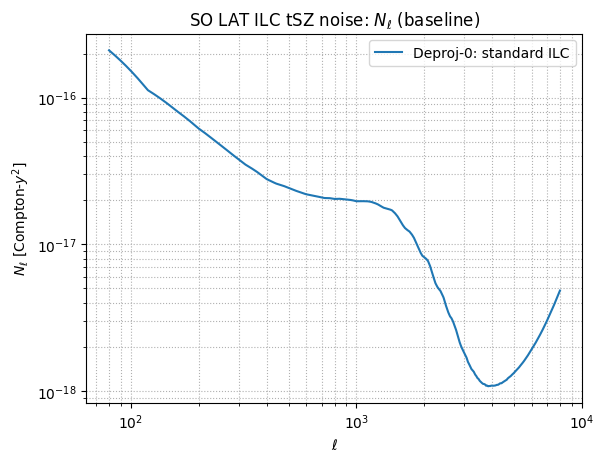

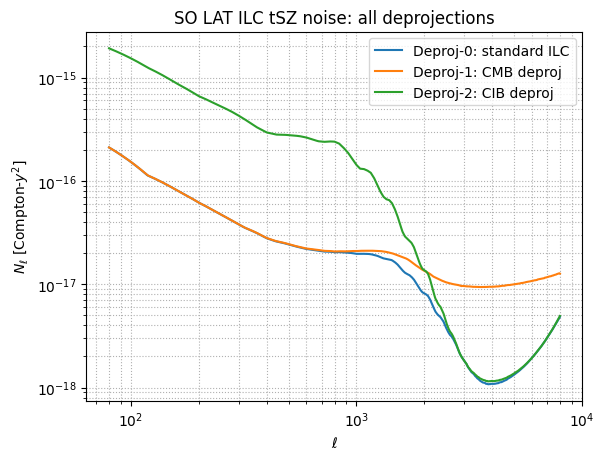

In [10]:
import numpy as np
import matplotlib.pyplot as plt

nell_file = "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt"

# Load all columns (comments starting with '#' are ignored automatically)
data = np.loadtxt(nell_file)

print("data shape:", data.shape)  # e.g. (N_ell, 4)

ell = data[:, 0]        # multipoles
Nell_0 = data[:, 1]     # Deproj-0: standard ILC tSZ noise
Nell_1 = data[:, 2]     # Deproj-1: CMB deproj (if you want)
Nell_2 = data[:, 3]     # Deproj-2: CIB deproj (if you want)

# Optional: D_ell for Deproj-0
Dl_0 = ell * (ell + 1) * Nell_0 / (2.0 * np.pi)

# Plot N_ell for the standard ILC (Deproj-0)
plt.figure()
plt.loglog(ell, Nell_0, label="Deproj-0: standard ILC")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$N_\ell$ [Compton-$y^2$]")
plt.title("SO LAT ILC tSZ noise: $N_\\ell$ (baseline)")
plt.grid(True, which="both", ls=":")
plt.legend()

# Optionally also plot the other deprojections
plt.figure()
plt.loglog(ell, Nell_0, label="Deproj-0: standard ILC")
plt.loglog(ell, Nell_1, label="Deproj-1: CMB deproj")
plt.loglog(ell, Nell_2, label="Deproj-2: CIB deproj")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$N_\ell$ [Compton-$y^2$]")
plt.title("SO LAT ILC tSZ noise: all deprojections")
plt.grid(True, which="both", ls=":")
plt.legend()

plt.show()

data shape: (7900, 5)


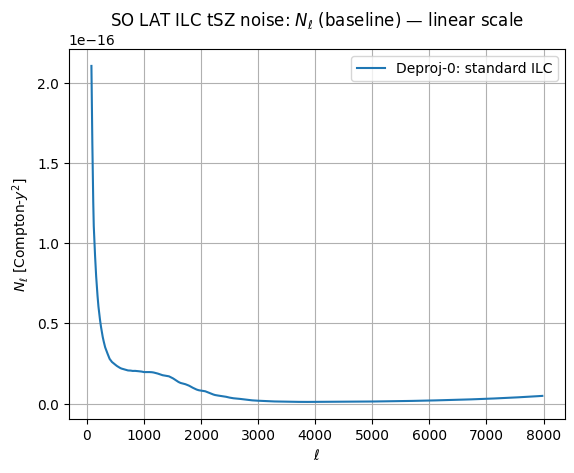

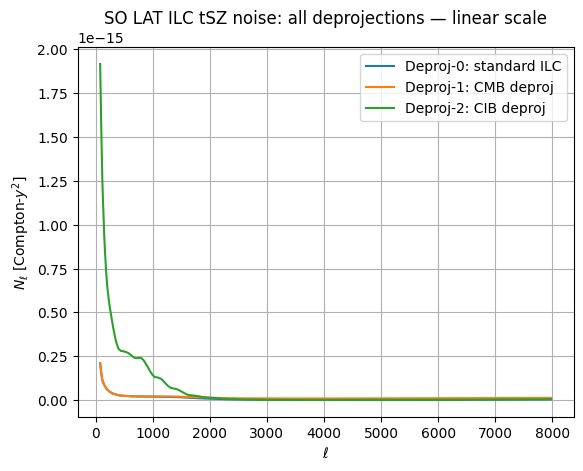

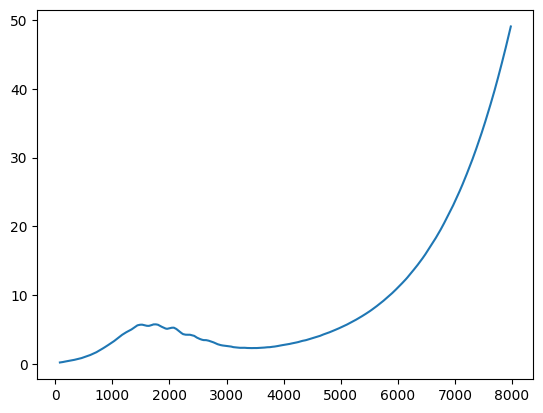

In [3]:
import numpy as np
import matplotlib.pyplot as plt

nell_file = "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt"

# Load all columns (comments starting with '#' are ignored automatically)
data = np.loadtxt(nell_file)

print("data shape:", data.shape)

ell = data[:, 0]        # multipoles
Nell_0 = data[:, 1]     # Deproj-0
Nell_1 = data[:, 2]     # Deproj-1
Nell_2 = data[:, 3]     # Deproj-2

# Optional: D_ell for Deproj-0
Dl_0 = ell * (ell + 1) * Nell_0 / (2.0 * np.pi)

# ----------------------------------------------------------
# 1) Plot N_ell (Deproj-0) en échelle linéaire
# ----------------------------------------------------------

plt.figure()
plt.plot(ell, Nell_0, label="Deproj-0: standard ILC")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$N_\ell$ [Compton-$y^2$]")
plt.title("SO LAT ILC tSZ noise: $N_\\ell$ (baseline) — linear scale")
plt.grid(True)
plt.legend()

# ----------------------------------------------------------
# 2) Plot toutes les déprojections en échelle linéaire
# ----------------------------------------------------------

plt.figure()
plt.plot(ell, Nell_0, label="Deproj-0: standard ILC")
plt.plot(ell, Nell_1, label="Deproj-1: CMB deproj")
plt.plot(ell, Nell_2, label="Deproj-2: CIB deproj")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$N_\ell$ [Compton-$y^2$]")
plt.title("SO LAT ILC tSZ noise: all deprojections — linear scale")
plt.grid(True)
plt.legend()

plt.show()

######
ell_file = data[:, 0]
Nell_0   = data[:, 1]  # C_ell^noise

# D_ell physique en y^2
Dl_file_phys = 1e12*ell_file * (ell_file + 1) * Nell_0 / (2.0 * np.pi)
plt.plot(ell, Dl_file_phys)

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from pixell import enmap

from so_tsz_noise_utils import noise_patch_from_nell, cl_from_enmap

# -----------------------
# 1) Chemins & paramètres
# -----------------------

YMAP_PATH = "/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paint_cov_big_sim/logA=2.96_Oc0h2=0.105217/y_map_10.0deg_0.500arcmin_235.fits"

NELL_FILE = "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt"  # à adapter vers ton chemin

NSIDE_NOISE = 2048
LMAX_CLIP   = 3 * NSIDE_NOISE - 1        # ou par ex. 3*NSIDE_NOISE - 1
SEED_NOISE  = 1234        # pour pouvoir reproduire

# Paramètres du calcul de spectre
BSIZE      = 300
MAX_ELL    = 10_000
APOD_WIDTH = 100
UNIT_SCALE = 1e12  # typique pour avoir D_ell ~ y^2 * 1e12

# -----------------------
# 2) Charge la carte signal
# -----------------------

imap_signal = enmap.read_map(YMAP_PATH)  # enmap.ndmap
print("Signal map shape:", imap_signal.shape)

# -----------------------
# 3) Génère un bruit SO sur la même géométrie
# -----------------------

noise_patch = noise_patch_from_nell(
    nell_file=NELL_FILE,
    template_map=imap_signal,
    nside=NSIDE_NOISE,
    lmax_clip=LMAX_CLIP,
    seed=SEED_NOISE,
    deproj=0,  # Deproj-0 = ILC standard
)

print("Noise patch shape:", noise_patch.shape)

# -----------------------
# 4) Carte signal + bruit
# -----------------------

imap_noisy = imap_signal + noise_patch

# -----------------------
# 5) Spectres de puissance
# -----------------------

ell_s, D_s = cl_from_enmap(
    imap_signal,
    bsize=BSIZE,
    max_ell=MAX_ELL,
    apod_width=APOD_WIDTH,
    unit_scale=UNIT_SCALE,
)

ell_n, D_n = cl_from_enmap(
    noise_patch,
    bsize=BSIZE,
    max_ell=MAX_ELL,
    apod_width=APOD_WIDTH,
    unit_scale=UNIT_SCALE,
)

ell_sn, D_sn = cl_from_enmap(
    imap_noisy,
    bsize=BSIZE,
    max_ell=MAX_ELL,
    apod_width=APOD_WIDTH,
    unit_scale=UNIT_SCALE,
)

# -----------------------
# 6) Plots de comparaison
# -----------------------

plt.figure(figsize=(7,5))
plt.plot(ell_s,  D_s,  label="Signal seul", lw=1.5)
plt.plot(ell_n,  D_n,  label="Bruit seul", lw=1.5)
plt.plot(ell_sn, D_sn, label="Signal + bruit", lw=1.5)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell \;[\mathrm{Compton-}y^2 \times 10^{12}]$")
plt.title("Spectres de puissance : signal, bruit, signal+bruit (patch 10°×10°)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# 7) Optionnel : vérifier que D_noise ~ N_ell * ell(ell+1)/(2π)
#    en tenant compte que tu es sur un patch, donc il y a du scatter.
# -----------------------



Signal map shape: (1200, 1200)


/rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/so_tsz_noise_utils.py:89: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  hp_map = hp.synfast(


Noise patch shape: (1200, 1200)


NameError: name 'phys' is not defined

Signal map shape: (1200, 1200)


/rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/so_tsz_noise_utils.py:89: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  hp_map = hp.synfast(


Noise patch shape: (1200, 1200)


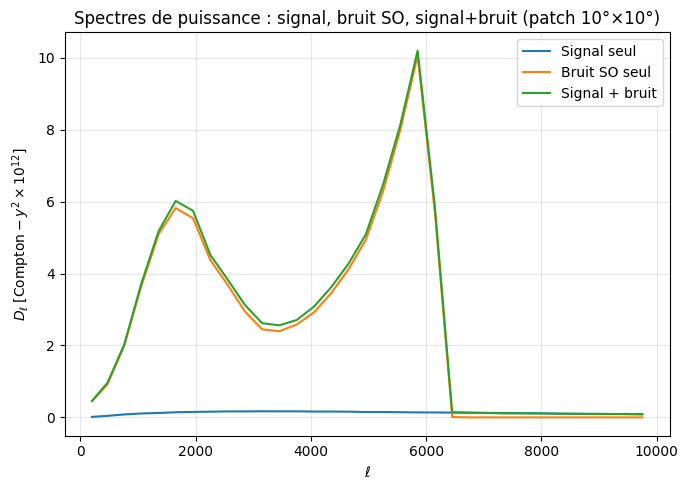

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from pixell import enmap

from so_tsz_noise_utils import noise_patch_from_nell, cl_from_enmap

# -----------------------
# 1) Chemins & paramètres
# -----------------------

YMAP_PATH = "/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paint_cov_big_sim/logA=2.96_Oc0h2=0.105217/y_map_10.0deg_0.500arcmin_235.fits"
# ou, si tu veux l’autre patch :
# YMAP_PATH = "/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paint_cov_big_sim/logA=2.77099_Oc0h2=0.129512/y_map_10.0deg_0.500arcmin_58.fits"

NELL_FILE = "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt"  # mets le chemin absolu si besoin

NSIDE_NOISE = 2048
LMAX_CLIP   = 3 * NSIDE_NOISE - 1   # lmax = 6143 (contrainte healpy)
SEED_NOISE  = 1234                  # pour pouvoir reproduire

# Paramètres du calcul de spectre (cohérents avec compute_dell_empirical)
BSIZE       = 300
MAX_ELL     = 10_000
APOD_WIDTH  = 100
UNIT_SCALE  = 1e12  # typique pour avoir D_ell ~ y^2 * 1e12

# -----------------------
# 2) Charge la carte signal
# -----------------------

imap_signal = enmap.read_map(YMAP_PATH)  # enmap.ndmap
print("Signal map shape:", imap_signal.shape)

# -----------------------
# 3) Génère un bruit SO sur la même géométrie
# -----------------------

noise_patch = noise_patch_from_nell(
    nell_file=NELL_FILE,
    template_map=imap_signal,
    nside=NSIDE_NOISE,
    lmax_clip=LMAX_CLIP,
    seed=SEED_NOISE,
    deproj=0,  # Deproj-0 = ILC standard
)

print("Noise patch shape:", noise_patch.shape)

# -----------------------
# 4) Carte signal + bruit
# -----------------------

imap_noisy = imap_signal + noise_patch

# -----------------------
# 5) Spectres de puissance (pipeline identique à compute_dell_empirical)
# -----------------------

ell_s,  D_s  = cl_from_enmap(
    imap_signal,
    bsize=BSIZE,
    max_ell=MAX_ELL,
    apod_width=APOD_WIDTH,
    unit_scale=UNIT_SCALE,
    normalize='phys',
)

ell_n,  D_n  = cl_from_enmap(
    noise_patch,
    bsize=BSIZE,
    max_ell=MAX_ELL,
    apod_width=APOD_WIDTH,
    unit_scale=UNIT_SCALE,
    normalize='phys',
)

ell_sn, D_sn = cl_from_enmap(
    imap_noisy,
    bsize=BSIZE,
    max_ell=MAX_ELL,
    apod_width=APOD_WIDTH,
    unit_scale=UNIT_SCALE,
    normalize='phys',
)

# -----------------------
# 6) Plots de comparaison
# -----------------------

plt.figure(figsize=(7,5))
plt.plot(ell_s,  D_s,  label="Signal seul",      lw=1.5)
plt.plot(ell_n,  D_n,  label="Bruit SO seul",    lw=1.5)
plt.plot(ell_sn, D_sn, label="Signal + bruit",   lw=1.5)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell \;[\mathrm{Compton-}y^2 \times 10^{12}]$")
plt.title("Spectres de puissance : signal, bruit SO, signal+bruit (patch 10°×10°)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Signal shape: (1200, 1200)


/rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/so_tsz_noise_utils.py:89: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  hp_map = hp.synfast(


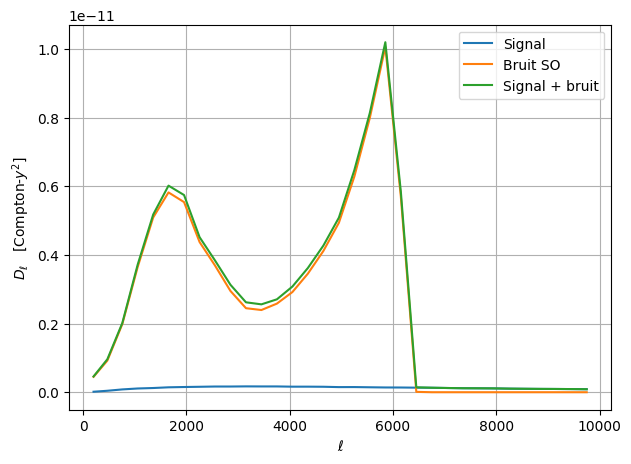

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from pixell import enmap

from so_tsz_noise_utils import noise_patch_from_nell, cl_from_enmap

# -----------------------
# 1) Chemins & paramètres
# -----------------------

YMAP_PATH = "/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paint_cov_big_sim/logA=2.96_Oc0h2=0.105217/y_map_10.0deg_0.500arcmin_235.fits"
NELL_FILE = "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt"

NSIDE_NOISE = 2048
LMAX_CLIP   = 3 * NSIDE_NOISE - 1
SEED_NOISE  = 1234

# IMPORTANT : pas de scaling !
UNIT_SCALE = 1

BSIZE       = 300
MAX_ELL     = 10_000
APOD_WIDTH  = 100

# -----------------------
# 2) Lecture de la carte
# -----------------------

imap_signal = enmap.read_map(YMAP_PATH)
print("Signal shape:", imap_signal.shape)

# -----------------------
# 3) Bruit SO sur le patch
# -----------------------

noise_patch = noise_patch_from_nell(
    nell_file=NELL_FILE,
    template_map=imap_signal,
    nside=NSIDE_NOISE,
    lmax_clip=LMAX_CLIP,
    seed=SEED_NOISE,
    deproj=0,
)

imap_noisy = imap_signal + noise_patch

# -----------------------
# 4) Spectres (sans scaling)
# -----------------------

ell_s,  D_s  = cl_from_enmap(imap_signal, bsize=BSIZE,
                             max_ell=MAX_ELL, apod_width=APOD_WIDTH,
                             unit_scale=UNIT_SCALE)

ell_n,  D_n  = cl_from_enmap(noise_patch, bsize=BSIZE,
                             max_ell=MAX_ELL, apod_width=APOD_WIDTH,
                             unit_scale=UNIT_SCALE)

ell_sn, D_sn = cl_from_enmap(imap_noisy, bsize=BSIZE,
                             max_ell=MAX_ELL, apod_width=APOD_WIDTH,
                             unit_scale=UNIT_SCALE)

# -----------------------
# 5) Plots
# -----------------------

plt.figure(figsize=(7,5))
plt.plot(ell_s,  D_s,  lw=1.5, label="Signal")
plt.plot(ell_n,  D_n,  lw=1.5, label="Bruit SO")
plt.plot(ell_sn, D_sn, lw=1.5, label="Signal + bruit")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$   [Compton-$y^2$]")
plt.grid(True)
plt.legend()
plt.show()


Signal shape: (1200, 1200)


/rds/rds-clecat/pipeline_alina_full/alina_paper/sbi_wst_5000/so_tsz_noise_utils.py:89: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  hp_map = hp.synfast(


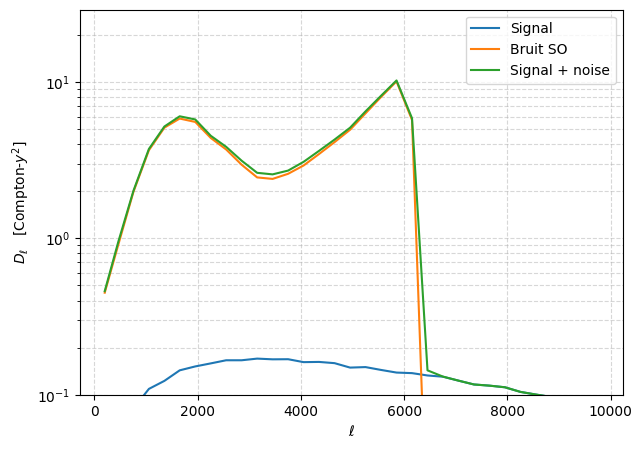

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from pixell import enmap

from so_tsz_noise_utils import noise_patch_from_nell, cl_from_enmap

# -----------------------
# 1) Chemins & paramètres
# -----------------------

YMAP_PATH = "/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paint_cov_big_sim/logA=2.96_Oc0h2=0.105217/y_map_10.0deg_0.500arcmin_235.fits"
NELL_FILE = "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt"

NSIDE_NOISE = 2048
LMAX_CLIP   = 3 * NSIDE_NOISE - 1
SEED_NOISE  = 1234

# IMPORTANT : pas de scaling !
UNIT_SCALE = 1

BSIZE       = 300
MAX_ELL     = 10_000
APOD_WIDTH  = 100

# -----------------------
# 2) Lecture de la carte
# -----------------------

imap_signal = enmap.read_map(YMAP_PATH)
print("Signal shape:", imap_signal.shape)

# -----------------------
# 3) Bruit SO sur le patch
# -----------------------

noise_patch = noise_patch_from_nell(
    nell_file=NELL_FILE,
    template_map=imap_signal,
    nside=NSIDE_NOISE,
    lmax_clip=LMAX_CLIP,
    seed=SEED_NOISE,
    deproj=0,
)

imap_noisy = imap_signal + noise_patch

# -----------------------
# 4) Spectres (sans scaling)
# -----------------------

ell_s,  D_s  = cl_from_enmap(imap_signal, bsize=BSIZE,
                             max_ell=MAX_ELL, apod_width=APOD_WIDTH,
                             unit_scale=UNIT_SCALE)

ell_n,  D_n  = cl_from_enmap(noise_patch, bsize=BSIZE,
                             max_ell=MAX_ELL, apod_width=APOD_WIDTH,
                             unit_scale=UNIT_SCALE)

ell_sn, D_sn = cl_from_enmap(imap_noisy, bsize=BSIZE,
                             max_ell=MAX_ELL, apod_width=APOD_WIDTH,
                             unit_scale=UNIT_SCALE)


#Plot

plt.figure(figsize=(7,5))
plt.plot(ell_s,  D_s,  lw=1.5, label="Signal")
plt.plot(ell_n,  D_n,  lw=1.5, label="Bruit SO")
plt.plot(ell_sn, D_sn, lw=1.5, label="Signal + noise")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$   [Compton-$y^2$]")

plt.yscale("log")
plt.ylim(bottom=1e-1)   # <-- limite log en ordonnée
# ou : plt.ylim(1e-1, None)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()
